# 🦍 Notebook 04 — Random Forest Survival Prediction
This notebook trains, evaluates, and interprets a **Random Forest classifier**
using scikit-learn.

**Pipeline:**
1. Load feature matrix
2. Temporal train/test split (avoid data leakage)
3. Handle class imbalance with SMOTE
4. Random Forest with cross-validation
5. Feature importance (MDI + permutation)
6. Model evaluation metrics
7. SHAP value interpretation


## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             RocCurveDisplay, precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import warnings, os

warnings.filterwarnings('ignore')
np.random.seed(42)
DATA_DIR = os.path.join('..', 'data')
print("✅ Libraries loaded")


✅ Libraries loaded


## Cell 2 — Load Feature Matrix

In [2]:
feat_df = pd.read_csv(os.path.join(DATA_DIR, 'feature_matrix.csv'))
print(f"Feature matrix shape: {feat_df.shape}")

FEATURES = [
    'age', 'age_class_ord', 'sex_binary',
    'group_size', 'n_silverbacks', 'multi_male_group',
    'prop_silverbacks', 'prop_adult_females', 'prop_infants',
    'dependency_ratio', 'habitat_quality_score',
    'dom_rank_norm', 'body_condition_score',
    'forage_pct', 'rest_pct', 'social_pct', 'travel_pct',
    'mean_foraging_pct', 'mean_agonistic', 'mean_affiliation',
    'social_integration', 'foraging_efficiency', 'cohesion_idx',
    'annual_rainfall_mm', 'lagged_rainfall_mm',
    'rainfall_anomaly_z', 'lagged_rain_z', 'rainfall_seasonality_idx',
]
TARGET = 'survived_next_year'

X = feat_df[FEATURES].fillna(feat_df[FEATURES].median())
y = feat_df[TARGET]

print(f"X: {X.shape}  |  y: {y.shape}")
print(f"Class balance: {y.mean()*100:.1f}% survived")


Feature matrix shape: (4080, 34)
X: (4080, 28)  |  y: (4080,)
Class balance: 98.2% survived


## Cell 3 — Temporal Train/Test Split
**Critical**: We split by year, not randomly, to avoid temporal data leakage.
Training on future data and testing on the past would give falsely optimistic results.


In [3]:
# Train: 2010–2020  |  Test: 2021–2023
train_mask = feat_df['year'] <= 2020
test_mask  = feat_df['year'] >  2020

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print("── Temporal split ───────────────────────────────────────────────────")
print(f"  Training  (2010–2020): {X_train.shape[0]} records  |  {y_train.mean()*100:.1f}% survived")
print(f"  Test      (2021–2023): {X_test.shape[0]} records   |  {y_test.mean()*100:.1f}% survived")

# ── Handle class imbalance ────────────────────────────────────────────────────
# Use class_weight='balanced' in RF instead of SMOTE (no external dependency needed)
print("\n⚠️  Class imbalance detected. Using class_weight='balanced' in RF.")
print("   This reweights minority class (deaths) during tree construction.")


── Temporal split ───────────────────────────────────────────────────
  Training  (2010–2020): 2895 records  |  98.1% survived
  Test      (2021–2023): 1185 records   |  98.5% survived

⚠️  Class imbalance detected. Using class_weight='balanced' in RF.
   This reweights minority class (deaths) during tree construction.


## Cell 4 — Train Random Forest

In [4]:
rf = RandomForestClassifier(
    n_estimators    = 500,       # number of trees
    max_depth       = None,      # grow full trees (pruned by min_samples)
    min_samples_leaf= 4,         # prevent overfitting to rare death events
    max_features    = 'sqrt',    # standard for classification
    class_weight    = 'balanced',# compensate for ~98% survival imbalance
    n_jobs          = -1,        # use all CPU cores
    random_state    = 42,
    oob_score       = True,      # out-of-bag accuracy (free validation)
)

rf.fit(X_train, y_train)

print("── Random Forest trained ────────────────────────────────────────────")
print(f"  n_estimators  : {rf.n_estimators}")
print(f"  OOB Accuracy  : {rf.oob_score_:.4f}  (out-of-bag = conservative estimate)")
print(f"  n_features    : {rf.n_features_in_}")


── Random Forest trained ────────────────────────────────────────────
  n_estimators  : 500
  OOB Accuracy  : 0.9796  (out-of-bag = conservative estimate)
  n_features    : 28


## Cell 5 — Cross-Validation (Stratified K-Fold)

── 5-Fold Stratified Cross-Validation (Training Set) ───────────────
  Roc Auc                  : 0.8939  (±0.0233)
  Average Precision        : 0.9977  (±0.0005)
  F1                       : 0.9901  (±0.0004)
  Balanced Accuracy        : 0.4996  (±0.0004)


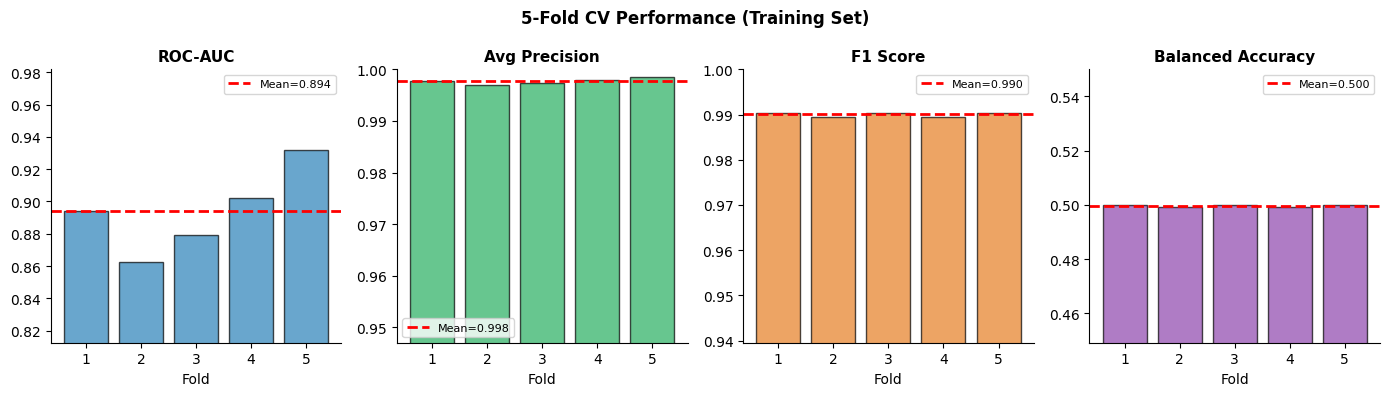

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    rf, X_train, y_train, cv=cv,
    scoring=['roc_auc','average_precision','f1','balanced_accuracy'],
    n_jobs=-1
)

print("── 5-Fold Stratified Cross-Validation (Training Set) ───────────────")
for metric, vals in cv_results.items():
    if metric.startswith('test_'):
        name = metric.replace('test_','').replace('_',' ').title()
        print(f"  {name:<25}: {vals.mean():.4f}  (±{vals.std():.4f})")

# Visual: CV score distribution
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
metrics = ['test_roc_auc','test_average_precision','test_f1','test_balanced_accuracy']
titles  = ['ROC-AUC','Avg Precision','F1 Score','Balanced Accuracy']
colors  = ['#2980b9','#27ae60','#e67e22','#8e44ad']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    vals = cv_results[metric]
    ax.bar(range(1, 6), vals, color=color, alpha=0.7, edgecolor='black')
    ax.axhline(vals.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={vals.mean():.3f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylim(max(0, vals.min()-0.05), min(1, vals.max()+0.05))
    ax.legend(fontsize=8)
    for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.suptitle('5-Fold CV Performance (Training Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..','data','04_cv_scores.png'), dpi=150, bbox_inches='tight')
plt.show()


## Cell 6 — Test Set Evaluation

In [6]:
y_pred      = rf.predict(X_test)
y_prob      = rf.predict_proba(X_test)[:, 1]   # probability of survival

print("── Test Set Classification Report ──────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=['Died (0)','Survived (1)']))

print(f"  ROC-AUC            : {roc_auc_score(y_test, y_prob):.4f}")
print(f"  Average Precision  : {average_precision_score(y_test, y_prob):.4f}")


── Test Set Classification Report ──────────────────────────────────
              precision    recall  f1-score   support

    Died (0)       0.00      0.00      0.00        18
Survived (1)       0.98      1.00      0.99      1167

    accuracy                           0.98      1185
   macro avg       0.49      0.50      0.50      1185
weighted avg       0.97      0.98      0.98      1185

  ROC-AUC            : 0.9037
  Average Precision  : 0.9984


## Cell 7 — Confusion Matrix & ROC/PR Curves

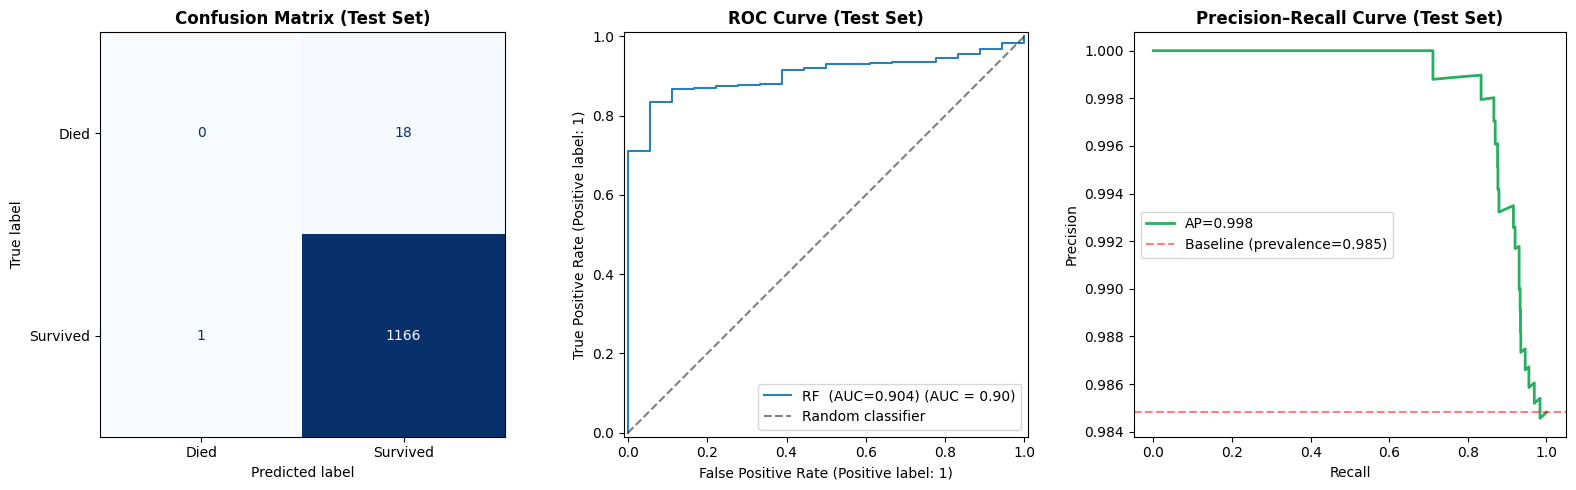

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Died','Survived']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
    name=f'RF  (AUC={roc_auc_score(y_test, y_prob):.3f})', color='#2980b9')
axes[1].plot([0,1],[0,1],'k--', alpha=0.5, label='Random classifier')
axes[1].set_title('ROC Curve (Test Set)', fontsize=12, fontweight='bold')
axes[1].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[2].plot(rec, prec, color='#27ae60', linewidth=2, label=f'AP={ap:.3f}')
axes[2].axhline(y_test.mean(), color='red', linestyle='--', alpha=0.5,
                label=f'Baseline (prevalence={y_test.mean():.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision–Recall Curve (Test Set)', fontsize=12, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join('..','data','04_model_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()


## Cell 8 — Feature Importance (Mean Decrease in Impurity)

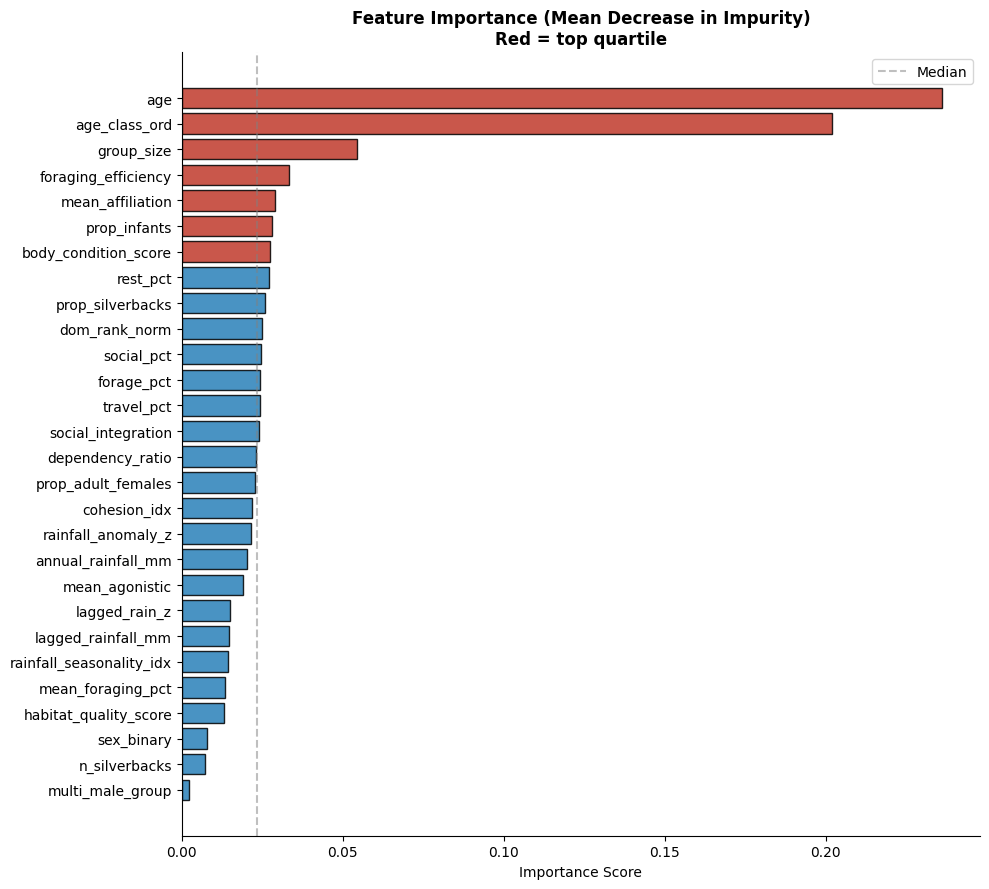

── Top 10 Features by MDI Importance ───────────────────────────────
age                     0.236076
age_class_ord           0.202030
group_size              0.054269
foraging_efficiency     0.033124
mean_affiliation        0.028818
prop_infants            0.027854
body_condition_score    0.027506
rest_pct                0.027099
prop_silverbacks        0.025684
dom_rank_norm           0.024791


In [8]:
importances = pd.Series(rf.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
colors_bar = ['#c0392b' if imp > importances.quantile(0.75) else '#2980b9'
              for imp in importances.values]
bars = ax.barh(importances.index[::-1], importances.values[::-1],
               color=colors_bar[::-1], edgecolor='black', alpha=0.85)
ax.set_title('Feature Importance (Mean Decrease in Impurity)\nRed = top quartile',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(importances.median(), color='gray', linestyle='--', alpha=0.5, label='Median')
ax.legend()
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join('..','data','04_feature_importance_mdi.png'), dpi=150, bbox_inches='tight')
plt.show()

print("── Top 10 Features by MDI Importance ───────────────────────────────")
print(importances.head(10).to_string())


## Cell 9 — Permutation Importance (More Reliable for Correlated Features)

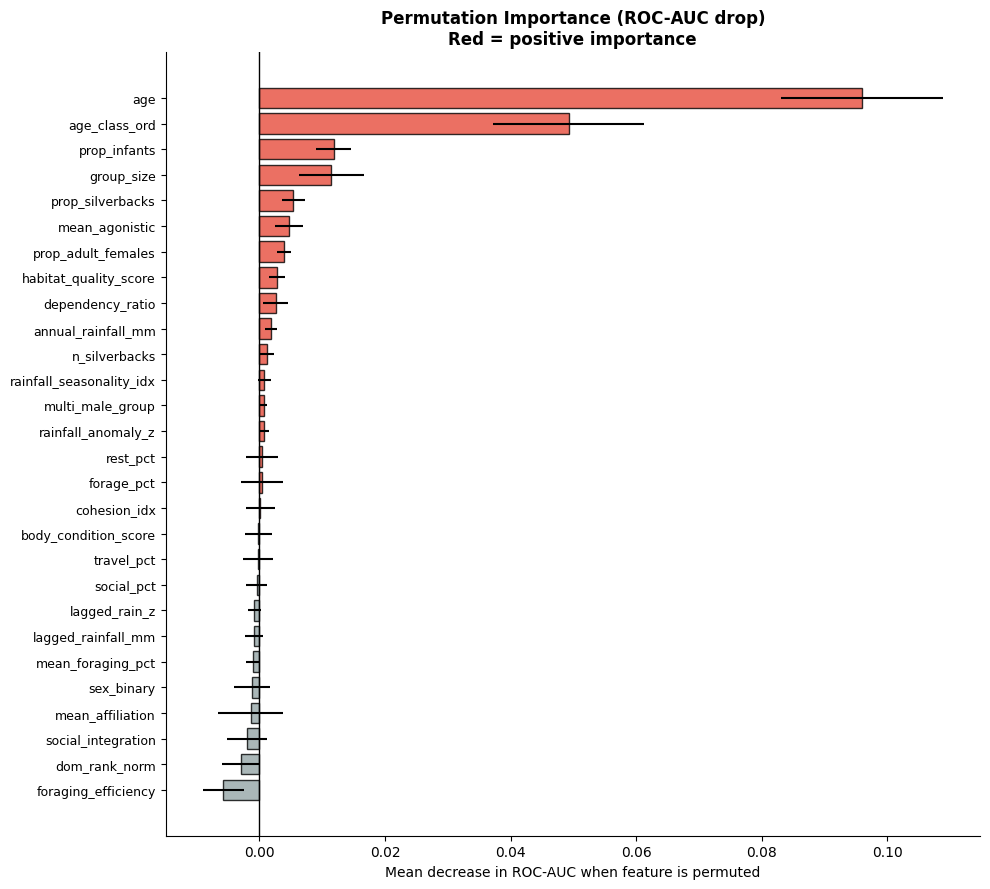

── Top 10 Features by Permutation Importance ───────────────────────
              feature  mean_imp  std_imp
                  age  0.095988 0.012884
        age_class_ord  0.049297 0.012030
         prop_infants  0.011839 0.002803
           group_size  0.011465 0.005180
     prop_silverbacks  0.005367 0.001824
       mean_agonistic  0.004721 0.002231
   prop_adult_females  0.003958 0.001132
habitat_quality_score  0.002794 0.001252
     dependency_ratio  0.002569 0.002041
   annual_rainfall_mm  0.001853 0.000951


In [9]:
perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=30, random_state=42,
    scoring='roc_auc', n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature'  : FEATURES,
    'mean_imp' : perm_result.importances_mean,
    'std_imp'  : perm_result.importances_std,
}).sort_values('mean_imp', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 9))
y_pos = range(len(perm_df))
ax.barh(y_pos, perm_df['mean_imp'][::-1],
        xerr=perm_df['std_imp'][::-1],
        color=['#e74c3c' if m > 0 else '#95a5a6' for m in perm_df['mean_imp'][::-1]],
        edgecolor='black', alpha=0.8)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(perm_df['feature'][::-1], fontsize=9)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Permutation Importance (ROC-AUC drop)\nRed = positive importance',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mean decrease in ROC-AUC when feature is permuted')
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join('..','data','04_permutation_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print("── Top 10 Features by Permutation Importance ───────────────────────")
print(perm_df.head(10).to_string(index=False))


## Cell 10 — Save Model Outputs

In [10]:
import pickle

# Save the trained model
with open(os.path.join(DATA_DIR, 'rf_gorilla_model.pkl'), 'wb') as f:
    pickle.dump(rf, f)

# Save feature importances
importances.reset_index().rename(columns={'index':'feature', 0:'mdi_importance'}).to_csv(
    os.path.join(DATA_DIR, 'feature_importances.csv'), index=False)

perm_df.to_csv(os.path.join(DATA_DIR, 'permutation_importances.csv'), index=False)

# Save test predictions
test_preds = feat_df[test_mask][['individual_id','group_name','year','age_class','sex']].copy()
test_preds['y_true']         = y_test.values
test_preds['y_pred']         = y_pred
test_preds['survival_prob']  = y_prob
test_preds.to_csv(os.path.join(DATA_DIR, 'test_predictions.csv'), index=False)

print("✅ Model and outputs saved:")
print(f"   rf_gorilla_model.pkl")
print(f"   feature_importances.csv")
print(f"   permutation_importances.csv")
print(f"   test_predictions.csv")
print("\n✅ Notebook 04 complete. Proceed to 05_visualization.ipynb")


✅ Model and outputs saved:
   rf_gorilla_model.pkl
   feature_importances.csv
   permutation_importances.csv
   test_predictions.csv

✅ Notebook 04 complete. Proceed to 05_visualization.ipynb
